In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [2]:
#Using xray data demonstrating my ability to handle data pipelines
#Binary Image Classification

#Step_1:Keras setup
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

# Verify the GPU is connected
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-03-17 15:44:17.478166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773762257.674956      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773762257.728416      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773762258.185333      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773762258.185388      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773762258.185391      55 computation_placer.cc:177] computation placer alr

Num GPUs Available:  1


In [3]:
#Step_2: Loading the Data
#Data Pipeline
# Data paths
train_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train'
valid_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val'

# Loading Training Data
ds_train = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='binary',
    image_size=[224, 224],
    batch_size=32,
    shuffle=True,
)

# Loading Validation Data
ds_valid = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels='inferred',
    label_mode='binary',
    image_size=[224, 224],
    batch_size=32,
    shuffle=False,
)

Found 5216 files belonging to 2 classes.


I0000 00:00:1773762292.763135      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 16 files belonging to 2 classes.


In [6]:
#Step_3: Defining the pre trained base 
#Convolutional Classifier
#Using VGG16 network
pretrained_base = tf.keras.applications.VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = [224,224,3]
)

#Freeze base layers
pretrained_base.trainable = False




In [7]:
#Step_4:
#Convolutional Classifier
#To avoid overfitting I am adding preprocessing
#Attach the classification head

preprocessing = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

model = keras.Sequential([
    pretrained_base,
    preprocessing,
    layers.Flatten(),
    layers.Dense(128, activation ='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation ='sigmoid'),
])

model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
#Step_5: Comiple the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

In [9]:
#Step_6: Train the model
#Use stochastic gradient

history = model.fit(
    ds_train,
    validation_data = ds_valid,
    epochs = 15,
    verbose = 1
)


Epoch 1/15


I0000 00:00:1773762378.033767     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 141ms/step - binary_accuracy: 0.8462 - loss: 4.6737 - val_binary_accuracy: 0.8125 - val_loss: 0.2107
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - binary_accuracy: 0.9574 - loss: 0.1092 - val_binary_accuracy: 0.9375 - val_loss: 0.1552
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - binary_accuracy: 0.9689 - loss: 0.0875 - val_binary_accuracy: 1.0000 - val_loss: 0.0297
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - binary_accuracy: 0.9748 - loss: 0.0774 - val_binary_accuracy: 0.9375 - val_loss: 0.1020
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - binary_accuracy: 0.9796 - loss: 0.0699 - val_binary_accuracy: 1.0000 - val_loss: 0.0325
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - binary_accuracy: 0.9817 - loss: 0.0690 - val_binary_accuracy: 1.0000 - val_loss: 0.0226
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - binary_accuracy: 0.9844 - loss: 0.0547 - val_binary_accuracy: 1.0000 - val_loss: 0.1243
Ep

<Axes: title={'center': 'Accuracy'}>

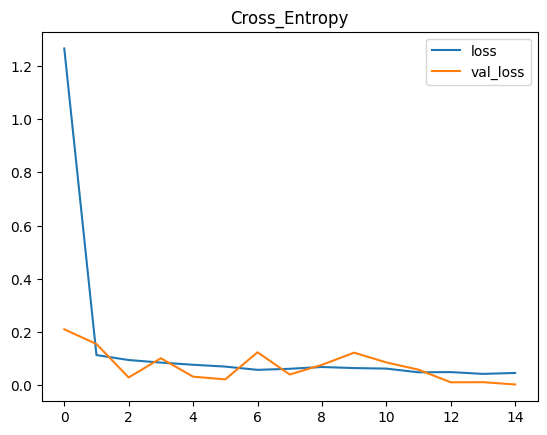

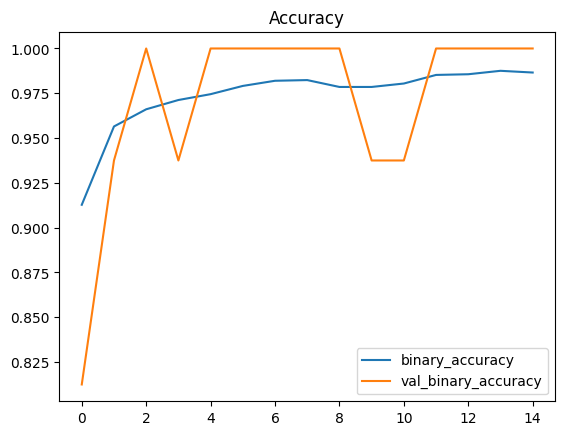

In [10]:
#Step_7
#Visulaizing underfitting and overfitting to check if changes are needed
history_df = pd.DataFrame(history.history)

#Plot the loss
history_df.loc[:,['loss', 'val_loss']].plot(title='Cross_Entropy')

#Plot the accuracy
history_df.loc[:,['binary_accuracy','val_binary_accuracy']].plot(title='Accuracy')

In [11]:
#Step_8: Evaluating test data
test_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test'

ds_test = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='binary',
    image_size=[224, 224],
    batch_size=32,
)

# 2. Run the Evaluation
results = model.evaluate(ds_test)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

Found 624 files belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - binary_accuracy: 0.8390 - loss: 1.2527
Test Loss: 1.4305846691131592
Test Accuracy: 0.8381410241127014


In [12]:
#Step_8 : Making a prediction
#I use 0.5 as a cut off value to judge if it is pneumonia or not
import numpy as np

image_batch, label_batch =next(iter(ds_test))
first_image = image_batch[0]
first_label = label_batch[0]
prediction = model.predict(np.expand_dims(first_image, axis=0))

print(f"Actual Label: {'Pneumonia' if first_label == 1 else 'Normal'}")
print(f"Model Probability: {prediction[0][0]:.2f}")
print(f"Model Guess: {'Pneumonia' if prediction[0][0] > 0.5 else 'Normal'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
Actual Label: Pneumonia
Model Probability: 1.00
Model Guess: Pneumonia
